<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/%20MONTES_DE_OCA-ANDRES-DL-TP1-Co25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 24 - 2do bimestre 2026

Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23:59 hs del jueves 21 de mayo (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP1 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/dMmn8VEJmvRmYgvi6)**. Tanto los resultados, tablas, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el mismo notebook.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL ÚNICO MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP1.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP1-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros a optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-10, fin=10`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado). Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para los 3 learning rates. Las 3 gráficas deben estar en el mismo plot para que la comparación visual sea más fácil.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Funciones Aux
def tanh(z):
    return np.tanh(z)

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def grad_mse_tanh(x, y_true, w, b):
    z = w * x + b
    y_pred = tanh(z)
    error = y_pred - y_true

    # Derivada de la activación tanh
    dtanh = 1 - y_pred**2

    # Gradientes vectorizados sobre el full batch
    dw = np.mean(2 * error * dtanh * x)
    db = np.mean(2 * error * dtanh)
    return dw, db, y_pred

In [ ]:
# Construcción del Dataset Sintético
np.random.seed(1515)
m = 1000
x = np.linspace(-10, 10, m)

# Mapeo sigmoidal y ruido gaussiano
ruido = np.random.normal(loc=0.0, scale=0.05, size=m)
y = 1 / (1 + np.exp(-x)) + ruido

# Setup
epochs = 100
learning_rates = [0.1, 0.01, 0.001]
w_init, b_init = np.random.randn(), np.random.randn()

# Proceso
historial_costos_gd = {}
y_pred_gd = {}

for lr in learning_rates:
    w, b = w_init, b_init
    costos = []

    for epoch in range(epochs):
        dw, db, y_pred = grad_mse_tanh(x, y, w, b)
        costos.append(mse_loss(y, y_pred))
        w -= lr * dw
        b -= lr * db

        if epoch == epochs - 1:
            y_pred_gd[lr] = y_pred

    historial_costos_gd[lr] = costos

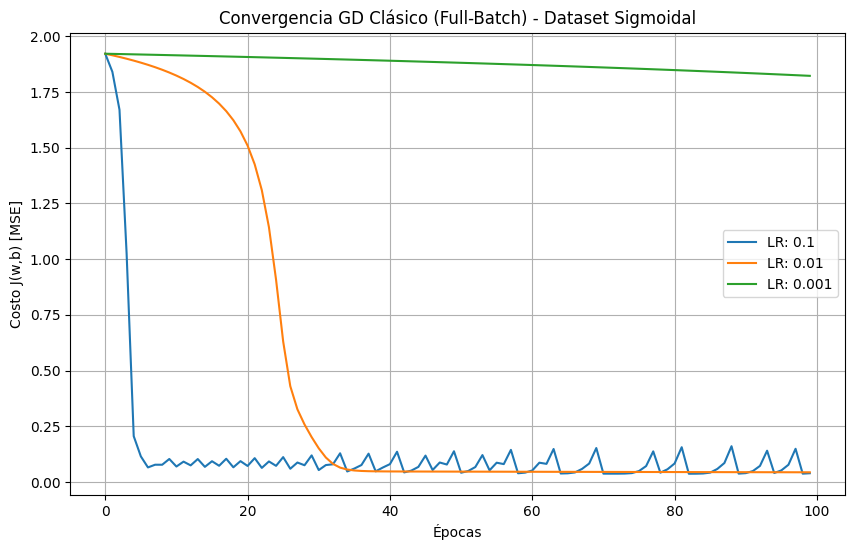

In [ ]:
# Plot
plt.figure(figsize=(10, 6))
for lr, costos in historial_costos_gd.items():
    plt.plot(range(epochs), costos, label=f'LR: {lr}')

plt.xlabel('Épocas')
plt.ylabel('Costo J(w,b) [MSE]')
plt.title('Convergencia GD Clásico (Full-Batch) - Dataset Sigmoidal')
plt.legend()
plt.grid(True)
plt.show()

- Se observa como con un LR muy pequeno, tarda demasiado en converger
- En cambio, con un LR muy grande, se converge rapido pero mucho mas inestable
- Y con un LR medio, se ve como demora mas en converger, pero la misma es mucho mas suave y estable

### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno sin mini-batch (full-batch) y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [ ]:
# Adam Full-Batch
batch_size = 128
beta1, beta2, epsilon = 0.9, 0.999, 1e-8

historial_costos_adam_full = {lr: [] for lr in learning_rates}
y_pred_adam_full = {}

for lr in learning_rates:

    w_f, b_f = w_init, b_init # Mismos valores usados antes
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0

    for t in range(1, epochs + 1):
        dw, db, y_pred = grad_mse_tanh(x, y, w_f, b_f)
        historial_costos_adam_full[lr].append(mse_loss(y, y_pred))

        # Propagación de estimadores de 1er y 2do momento con corrección de sesgo (W)
        m_w = beta1 * m_w + (1 - beta1) * dw
        v_w = beta2 * v_w + (1 - beta2) * (dw**2)
        w_f -= lr * (m_w / (1 - beta1**t)) / (np.sqrt(v_w / (1 - beta2**t)) + epsilon)

        # Propagación de estimadores de 1er y 2do momento con corrección de sesgo (B)
        m_b = beta1 * m_b + (1 - beta1) * db
        v_b = beta2 * v_b + (1 - beta2) * (db**2)
        b_f -= lr * (m_b / (1 - beta1**t)) / (np.sqrt(v_b / (1 - beta2**t)) + epsilon)


        if t == epochs:
            y_pred_adam_full[lr] = y_pred


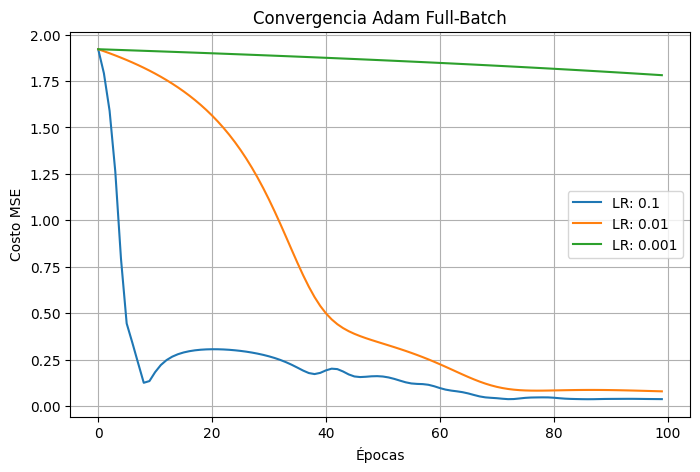

In [ ]:
# Plot

plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(range(epochs), historial_costos_adam_full[lr], label=f'LR: {lr}')
plt.xlabel('Épocas')
plt.ylabel('Costo MSE')
plt.title('Convergencia Adam Full-Batch')
plt.legend()
plt.grid(True)

* A diferencia del Descenso de Gradiente clasico, con un LR grande se logra estabilizar
* Hay un rebote inicial, pero los momentos del optimizador amortiguan el salto y lo llevan a convergencia

In [ ]:
# Adam Mini-Batch


historial_costos_adam_mini = {}
y_pred_adam_mini = {}

for lr in learning_rates:
    w_m, b_m = w_init, b_init # Mismos valores usados antes

    # Inicialización nula de estimadores de momento
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0
    t_m = 1
    costos = []

    for epoch in range(epochs):

        indices = np.random.permutation(m)
        x_shuf, y_shuf = x[indices], y[indices]

        for i in range(0, m, batch_size):
            # Extracción asimétrica de tensores de lote
            x_b = x_shuf[i:i + batch_size]
            y_b = y_shuf[i:i + batch_size]

            # Aproximación del gradiente sobre el sub-tensor X_b
            dw, db, _ = grad_mse_tanh(x_b, y_b, w_m, b_m)

            # Estimadores de momento y corrección de sesgo adaptativo (Tensor W)
            m_w = beta1 * m_w + (1 - beta1) * dw
            v_w = beta2 * v_w + (1 - beta2) * (dw**2)
            m_w_hat = m_w / (1 - beta1**t_m)
            v_w_hat = v_w / (1 - beta2**t_m)
            w_m -= lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)

            # Estimadores de momento y corrección de sesgo adaptativo (Escalar B)
            m_b = beta1 * m_b + (1 - beta1) * db
            v_b = beta2 * v_b + (1 - beta2) * (db**2)
            m_b_hat = m_b / (1 - beta1**t_m)
            v_b_hat = v_b / (1 - beta2**t_m)
            b_m -= lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

            t_m += 1

        # Evaluación del costo global sobre la matriz X completa tras iterar los n/b lotes
        _, _, y_pred_full = grad_mse_tanh(x, y, w_m, b_m)
        costos.append(mse_loss(y, y_pred_full))

        if epoch == epochs - 1:
            y_pred_adam_mini[lr] = y_pred_full

    historial_costos_adam_mini[lr] = costos

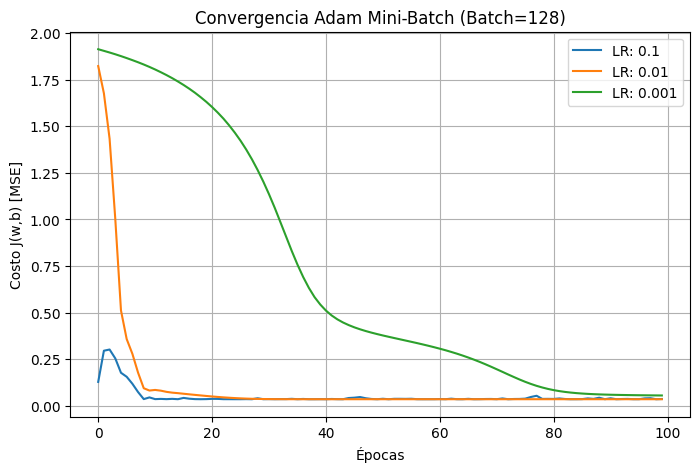

In [ ]:
# Plot
plt.figure(figsize=(8, 5))
for lr, costos in historial_costos_adam_mini.items():
    plt.plot(range(epochs), costos, label=f'LR: {lr}')

plt.xlabel('Épocas')
plt.ylabel('Costo J(w,b) [MSE]')
plt.title(f'Convergencia Adam Mini-Batch (Batch={batch_size})')
plt.legend()
plt.grid(True)
plt.show()

* Al actualizar los pesos por cada lote (y no al final de toda la epoca), el tiempo de convergencia se reduce para todos los LRs
* Esto permite converger utilizando LRs pequenos, a diferencia de los metodos anteruires

### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes.

Métricas de convergencia terminal (Época 100):


<>:32: SyntaxWarning: invalid escape sequence '\h'
<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:32: SyntaxWarning: invalid escape sequence '\h'
<>:51: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1267/3516364085.py:32: SyntaxWarning: invalid escape sequence '\h'
  fig.suptitle('Mapeo No Lineal: Inferencia $\hat{y}$ vs Función Subyacente $y(x)$', fontsize=14, fontweight='bold')
/tmp/ipykernel_1267/3516364085.py:51: SyntaxWarning: invalid escape sequence '\h'
  ax.plot(x[idx_sort], predicciones[lr][idx_sort], color='red', linewidth=2, label='Inferencia $\hat{y}$')


,Learning Rate (η),GD (MSE),Adam Full-Batch (MSE),Adam Mini-Batch (MSE)
0,0.100,0.039277,0.036868,0.037456
1,0.010,0.043528,0.078840,0.036288
2,0.001,1.822200,1.781575,0.056346


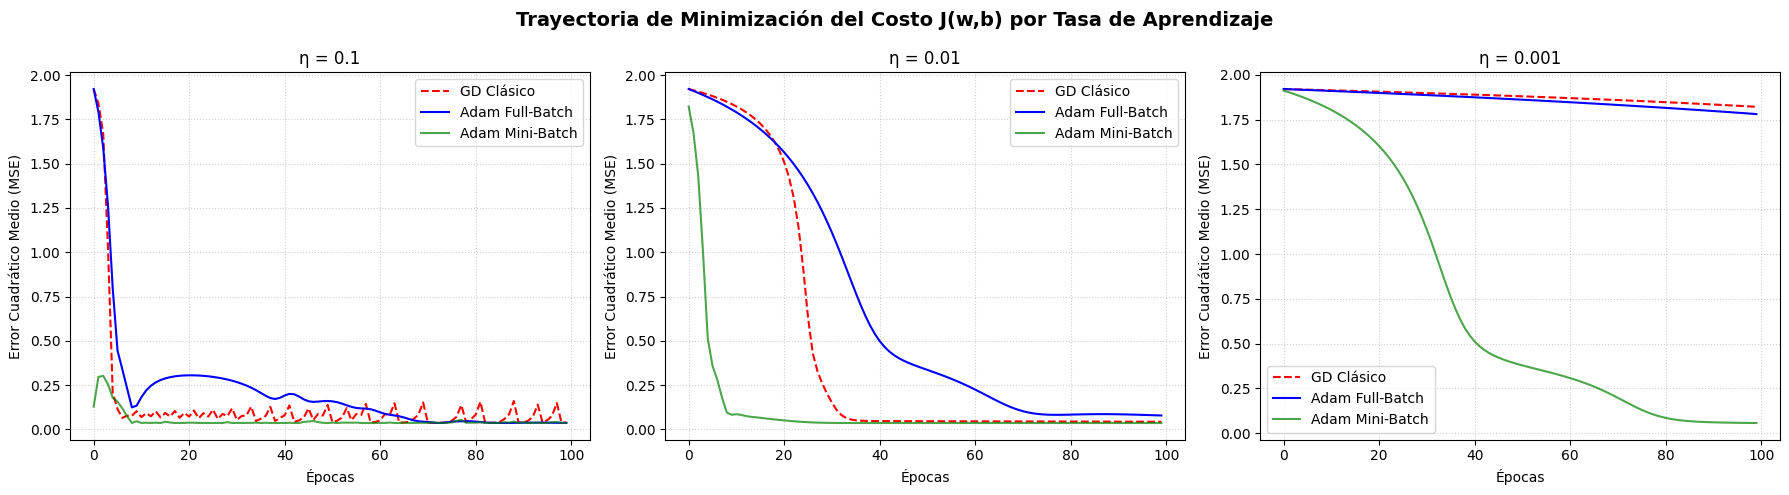

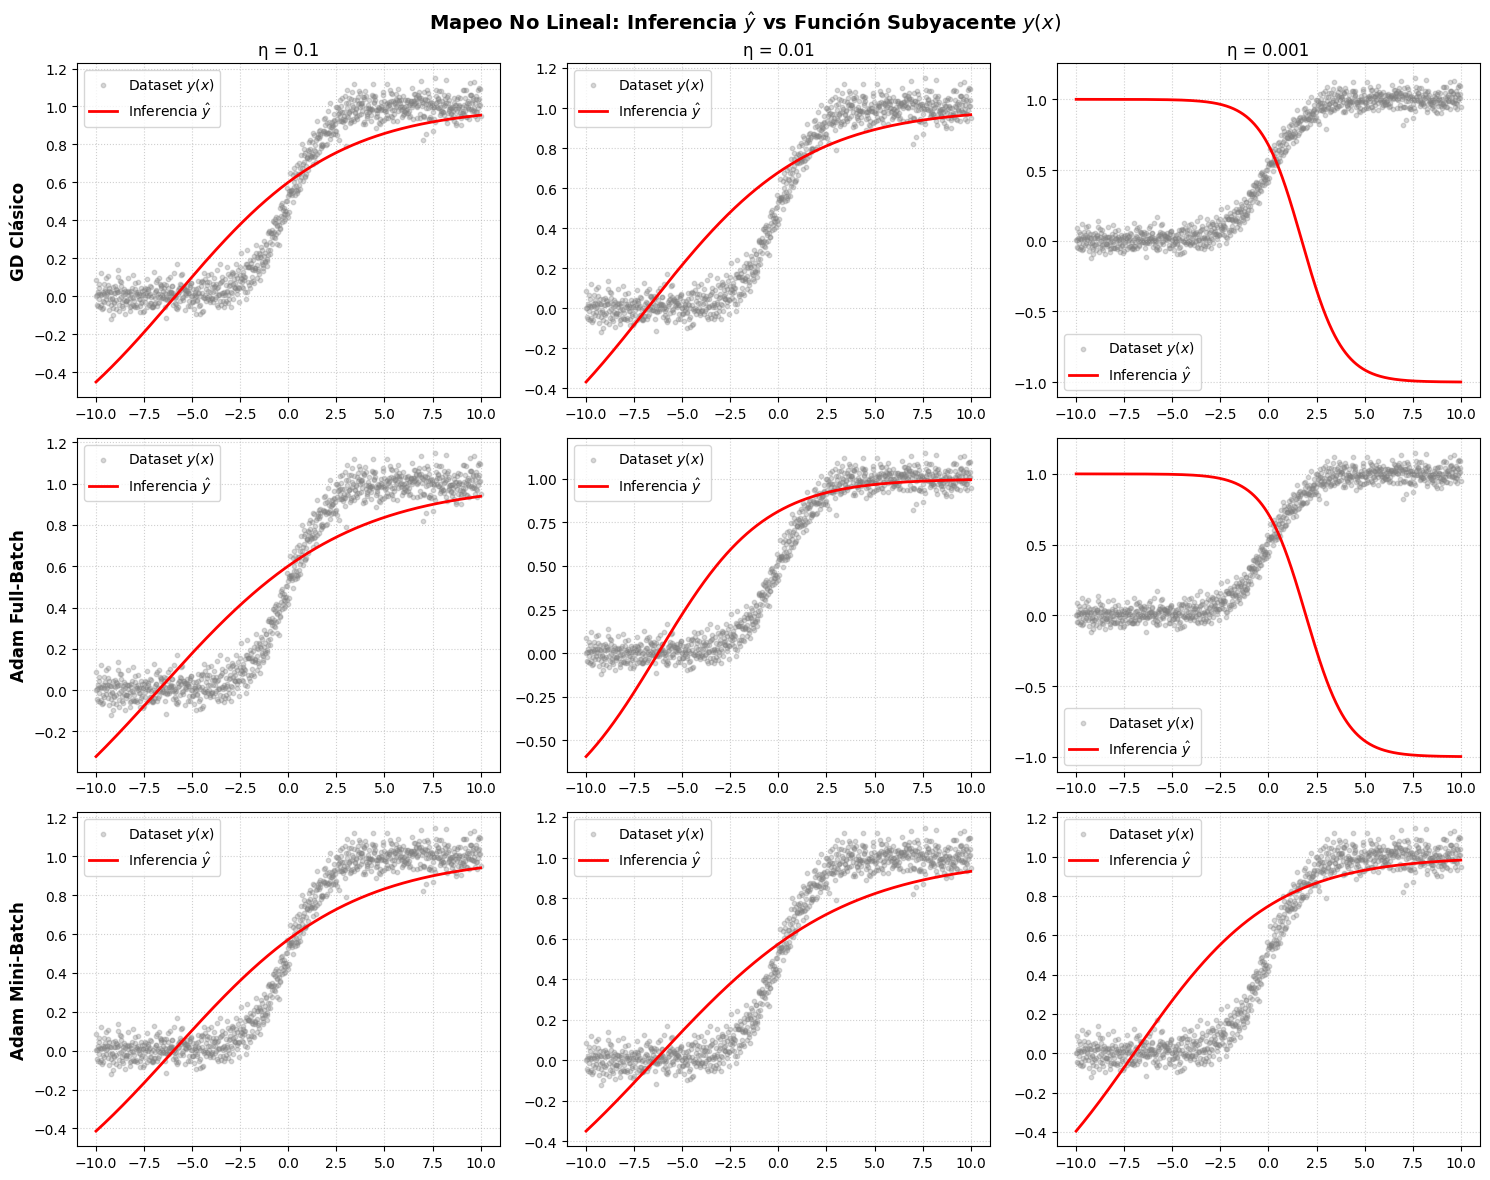

In [ ]:
# 1. Matriz Analítica de Rendimiento Asintótico
df_mse = pd.DataFrame({
    'Learning Rate (η)': learning_rates,
    'GD (MSE)': [historial_costos_gd[lr][-1] for lr in learning_rates], # Puntero adaptado a tu nomenclatura base
    'Adam Full-Batch (MSE)': [historial_costos_adam_full[lr][-1] for lr in learning_rates],
    'Adam Mini-Batch (MSE)': [historial_costos_adam_mini[lr][-1] for lr in learning_rates]
})

print("Métricas de convergencia terminal (Época 100):")
display(df_mse)

# 2. Análisis Topológico de la Convergencia de J(w,b) (3 Subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Trayectoria de Minimización del Costo J(w,b) por Tasa de Aprendizaje', fontsize=14, fontweight='bold')

for i, lr in enumerate(learning_rates):
    axes[i].plot(range(epochs), historial_costos_gd[lr], label='GD Clásico', linestyle='--', color='red')
    axes[i].plot(range(epochs), historial_costos_adam_full[lr], label='Adam Full-Batch', color='blue')
    axes[i].plot(range(epochs), historial_costos_adam_mini[lr], label='Adam Mini-Batch', color='green', alpha=0.7)

    axes[i].set_title(f'η = {lr}')
    axes[i].set_xlabel('Épocas')
    axes[i].set_ylabel('Error Cuadrático Medio (MSE)')
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Proyección del Hiperplano Inferido vs Dataset Original (Grilla 3x3)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Mapeo No Lineal: Inferencia $\hat{y}$ vs Función Subyacente $y(x)$', fontsize=14, fontweight='bold')

optimizadores = [
    ('GD Clásico', y_pred_gd), # Reemplazar por y_pred si no utilizaste el sufijo _gd
    ('Adam Full-Batch', y_pred_adam_full),
    ('Adam Mini-Batch', y_pred_adam_mini)
]

# Ordenamiento del tensor unidimensional para asegurar una interpolación continua
idx_sort = np.argsort(x)

for row, (nombre_opt, predicciones) in enumerate(optimizadores):
    for col, lr in enumerate(learning_rates):
        ax = axes[row, col]

        # Dispersión estocástica del dataset
        ax.scatter(x, y, color='gray', alpha=0.3, label='Dataset $y(x)$', s=10)

        # Interpolación de la predicción
        ax.plot(x[idx_sort], predicciones[lr][idx_sort], color='red', linewidth=2, label='Inferencia $\hat{y}$')

        if row == 0:
            ax.set_title(f'η = {lr}')
        if col == 0:
            ax.set_ylabel(nombre_opt, fontweight='bold', fontsize=12)

        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend()

plt.tight_layout()
plt.show()

- Para los LRs de 0.1 y 0.01, los tres algoritmos predicen bastante bien, con un MSE que ronda entre 0.035 y 0.7
- Tambien se observa en los plots, como como para esos LRs, la inferencia sigue el mismo patron que la distribucion original (sigmpode + random)
- En cambio para el LR mas chico (0.001), los algoritmos GD y Adan Full Batch no convergen. Desvanecimiento del Gradiente? Minimo Local?

- Adam Mini-Batch demuestra robustez transversal, logrando converger eficientemente y replicando la función subyacente de manera decente


### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia.

In [ ]:
# GD Clásico
historial_w_gd = {} # Almacena w en cada época
historial_b_gd = {} # Almacena b en cada época

for lr in learning_rates:
    w, b = w_init, b_init
    ws, bs = [], []
    for epoch in range(epochs):
        ws.append(w)
        bs.append(b)
        dw, db, _ = grad_mse_tanh(x, y, w, b)
        w -= lr * dw
        b -= lr * db
    historial_w_gd[lr] = ws
    historial_b_gd[lr] = bs

# Adam Full-Batch
historial_w_adam_full = {} # Almacena w en cada época
historial_b_adam_full = {} # Almacena b en cada época

for lr in learning_rates:
    w_f, b_f = w_init, b_init
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0
    ws_f, bs_f = [], []
    for t in range(1, epochs + 1):
        ws_f.append(w_f)
        bs_f.append(b_f)
        dw, db, _ = grad_mse_tanh(x, y, w_f, b_f)

        m_w = beta1 * m_w + (1 - beta1) * dw
        v_w = beta2 * v_w + (1 - beta2) * (dw**2)
        w_f -= lr * (m_w / (1 - beta1**t)) / (np.sqrt(v_w / (1 - beta2**t)) + epsilon)

        m_b = beta1 * m_b + (1 - beta1) * db
        v_b = beta2 * v_b + (1 - beta2) * (db**2)
        b_f -= lr * (m_b / (1 - beta1**t)) / (np.sqrt(v_b / (1 - beta2**t)) + epsilon)
    historial_w_adam_full[lr] = ws_f
    historial_b_adam_full[lr] = bs_f

# Adam Mini-Batch
historial_w_adam_mini = {} # Almacena w en cada época
historial_b_adam_mini = {} # Almacena b en cada época

for lr in learning_rates:
    w_m, b_m = w_init, b_init
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0
    t_m = 1
    ws_m, bs_m = [], []

    for epoch in range(epochs):
        # Almacenar w y b al inicio de cada época (después de las actualizaciones del epoch anterior)
        ws_m.append(w_m)
        bs_m.append(b_m)

        indices = np.random.permutation(m)
        x_shuf, y_shuf = x[indices], y[indices]

        for i in range(0, m, batch_size):
            x_b = x_shuf[i:i + batch_size]
            y_b = y_shuf[i:i + batch_size]
            dw, db, _ = grad_mse_tanh(x_b, y_b, w_m, b_m)

            m_w = beta1 * m_w + (1 - beta1) * dw
            v_w = beta2 * v_w + (1 - beta2) * (dw**2)
            m_w_hat = m_w / (1 - beta1**t_m)
            v_w_hat = v_w / (1 - beta2**t_m)
            w_m -= lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)

            m_b = beta1 * m_b + (1 - beta1) * db
            v_b = beta2 * v_b + (1 - beta2) * (db**2)
            m_b_hat = m_b / (1 - beta1**t_m)
            v_b_hat = v_b / (1 - beta2**t_m)
            b_m -= lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

            t_m += 1

    historial_w_adam_mini[lr] = ws_m
    historial_b_adam_mini[lr] = bs_m

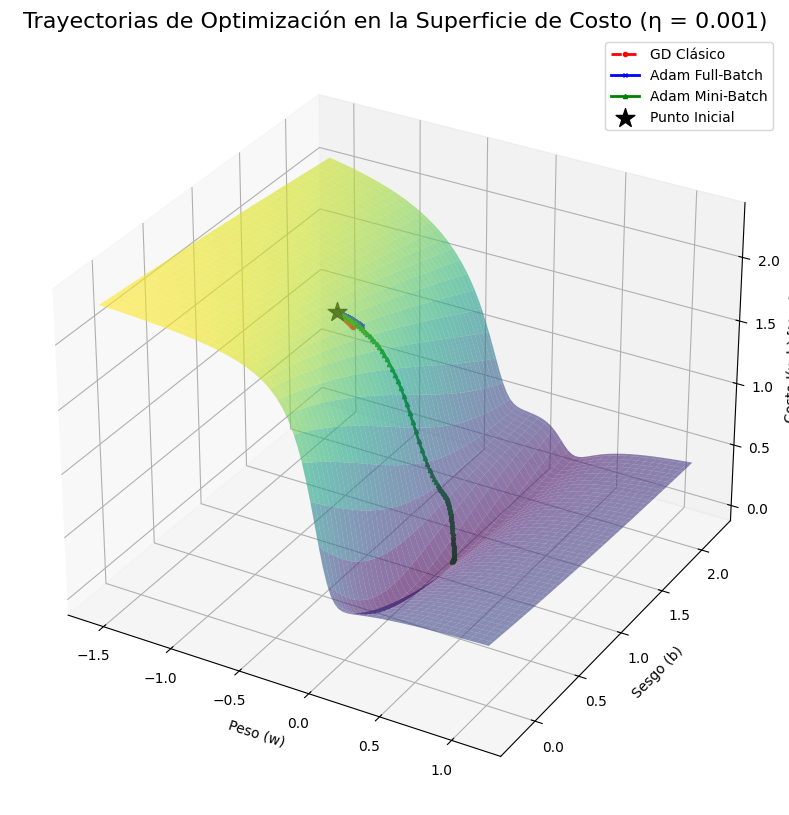

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Definir la función de costo J(w, b) para la superficie
def J_surface(w, b, X_data, y_data):
    cost_val = np.zeros_like(w)
    for i in range(w.shape[0]):
        for j in range(w.shape[1]):
            z = w[i, j] * X_data + b[i, j]
            y_pred = tanh(z)
            cost_val[i, j] = mse_loss(y_data, y_pred)
    return cost_val

# Seleccionar un learning rate para la visualización 3D
l_rate_3d = 0.001

# Obtener las trayectorias para el LR seleccionado
trajectory_w_gd = historial_w_gd[l_rate_3d]
trajectory_b_gd = historial_b_gd[l_rate_3d]
trajectory_J_gd = historial_costos_gd[l_rate_3d]

trajectory_w_adam_full = historial_w_adam_full[l_rate_3d]
trajectory_b_adam_full = historial_b_adam_full[l_rate_3d]
trajectory_J_adam_full = historial_costos_adam_full[l_rate_3d]

trajectory_w_adam_mini = historial_w_adam_mini[l_rate_3d]
trajectory_b_adam_mini = historial_b_adam_mini[l_rate_3d]
trajectory_J_adam_mini = historial_costos_adam_mini[l_rate_3d]

# Definir el rango para w y b para la superficie de costo
# Ajustar los límites para que cubran las trayectorias de los tres optimizadores
min_w = min(np.min(trajectory_w_gd), np.min(trajectory_w_adam_full), np.min(trajectory_w_adam_mini)) - 1
max_w = max(np.max(trajectory_w_gd), np.max(trajectory_w_adam_full), np.max(trajectory_w_adam_mini)) + 1
min_b = min(np.min(trajectory_b_gd), np.min(trajectory_b_adam_full), np.min(trajectory_b_adam_mini)) - 1
max_b = max(np.max(trajectory_b_gd), np.max(trajectory_b_adam_full), np.max(trajectory_b_adam_mini)) + 1

w_range = np.linspace(min_w, max_w, 100)
b_range = np.linspace(min_b, max_b, 100)
W, B = np.meshgrid(w_range, b_range)

# Calcular la superficie de costo
Z = J_surface(W, B, x, y)

# Graficar
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

# Superficie de costo
ax.plot_surface(W, B, Z, cmap='viridis', alpha=0.6)

# Trayectoria GD Clásico
ax.plot(trajectory_w_gd, trajectory_b_gd, trajectory_J_gd,
        label='GD Clásico', color='red', marker='o', markersize=3, linestyle='--', linewidth=2)

# Trayectoria Adam Full-Batch
ax.plot(trajectory_w_adam_full, trajectory_b_adam_full, trajectory_J_adam_full,
        label='Adam Full-Batch', color='blue', marker='x', markersize=3, linestyle='-', linewidth=2)

# Trayectoria Adam Mini-Batch
ax.plot(trajectory_w_adam_mini, trajectory_b_adam_mini, trajectory_J_adam_mini,
        label='Adam Mini-Batch', color='green', marker='^', markersize=3, linestyle='-', linewidth=2)

# Punto inicial (todos comienzan en el mismo lugar)
ax.scatter(w_init, b_init, historial_costos_gd[l_rate_3d][0],
           color='black', marker='*', s=200, label='Punto Inicial', zorder=10)

ax.set_xlabel('Peso (w)')
ax.set_ylabel('Sesgo (b)')
ax.set_zlabel('Costo J(w,b) [MSE]')
ax.set_title(f'Trayectorias de Optimización en la Superficie de Costo (η = {l_rate_3d})', fontsize=16)
ax.legend()
plt.show()

- Para un learning rate pequeño como 0.001, los métodos que dependen de gradientes más estables (GD y Adam Full-Batch) pueden volverse excesivamente lentos y quedar atrapados (no converger)
- En contraste, Adam Mini-Batch, con su combinación de momentos adaptativos y ruido de mini-batches, puede navegar la superficie de costo de manera más dinámica y eficiente, logrando la convergencia donde otros fallan

### **RECOMENDACIÓN**:

Voy a valorar mucho que sus análisis, explicaciones y conclusiones sean bastante detalladas y con coherencia en los resultados obtenidos. Donde se evidencie un análisis propio de un humano estudiante de posgrado y no solo copiar y pegar lo que te dijo ChatGPT. Llevo ya años con esto, así que me daré cuenta rapidamente cuando sea así y cuando no.

Les recomiendo revisar el notebook sobre optimizadores que se encuentra en el repo. Pueden acceder mediante el siguiente [enlace](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_2026/CLASE%202/Notebooks/clase2_4_optimizadores.ipynb). En ese notebook vemos cómo aplicar GD y Adam full-batch para una red con relación lineal. Les servirá mucho como guía para realizar esta pregunta. Ahí también podrán ver cómo se hace una animación de un gráfico 3D.

Además, de igual forma tienen disponible el siguiente [material adicional del repo](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/tree/ap_2026/CLASE%202/Teoria/Material%20adicional), el cual le servirá para aplicar Adam, ya no solo en su versión full-batch, sino también en mini-batch

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual.


### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


In [1]:
import pandas as pd
import gdown
import os

# Google Drive file ID for the dataset
file_id = '1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ'

# Output filename
output_filename = 'customer_data.csv'

# Download the file from Google Drive using gdown
gdown.download(id=file_id, output=output_filename, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ
To: /content/customer_data.csv
100%|██████████| 8.41M/8.41M [00:00<00:00, 58.9MB/s]


'customer_data.csv'

In [2]:
# Load the CSV file into a pandas DataFrame
data = pd.read_csv(output_filename)

# Display the first 5 rows of the DataFrame
print(f"Successfully loaded '{output_filename}' into a DataFrame. First 5 rows:")
display(data.head())

Successfully loaded 'customer_data.csv' into a DataFrame. First 5 rows:


,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142


In [3]:
print(f"Shape of the DataFrame: {data.shape}")
print("Data types of the columns:")
display(data.info())

Shape of the DataFrame: (182721, 11)
Data types of the columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     182721 non-null  int64  
 1   Product_ID                  182721 non-null  object 
 2   Age                         182721 non-null  object 
 3   Gender                      182721 non-null  object 
 4   Marital_Status              182721 non-null  int64  
 5   City_Category               182721 non-null  object 
 6   Stay_In_Current_City_Years  182721 non-null  object 
 7   Product_Category            182721 non-null  int64  
 8   Product_Subcategory_1       140903 non-null  float64
 9   Product_Subcategory_2       77461 non-null   float64
 10  Purchase                    182721 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 15.3+ MB


None

In [4]:
print("Percentage of missing values per column:")
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Percentage': missing_percentage})
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Percentage', ascending=False))

Percentage of missing values per column:


,Missing Count,Percentage
Product_Subcategory_2,105260,57.606953
Product_Subcategory_1,41818,22.886258


In [5]:
# Drop 'Product_Subcategory_2' due to a high percentage of missing values
data = data.drop('Product_Subcategory_2', axis=1)
print("Dropped 'Product_Subcategory_2' column.")

# Impute missing values in 'Product_Subcategory_1' with -1 (treating as 'unknown category')
data['Product_Subcategory_1'] = data['Product_Subcategory_1'].fillna(-1).astype(int)
print("Imputed missing values in 'Product_Subcategory_1' with -1 and converted to integer type.")

# Verify that missing values have been handled
print("\nVerifying remaining missing values:")
display(data.isnull().sum())

Dropped 'Product_Subcategory_2' column.
Imputed missing values in 'Product_Subcategory_1' with -1 and converted to integer type.

Verifying remaining missing values:


,0
User_ID,0
Product_ID,0
Age,0
Gender,0
Marital_Status,0
City_Category,0
Stay_In_Current_City_Years,0
Product_Category,0
Product_Subcategory_1,0
Purchase,0


In [6]:
# Identify categorical columns (object dtype)
categorical_cols = data.select_dtypes(include='object').columns

print("Unique values and counts for categorical columns:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    display(data[col].value_counts())
    print(f"Number of unique values: {data[col].nunique()}")

Unique values and counts for categorical columns:

Column: Product_ID


,count
Product_ID,
P00047292,220
P00038881,210
P00001575,208
P00071018,207
P00089916,206
...,...
P00017818,31
P00041029,30
P00005451,30


Number of unique values: 2455

Column: Age


,count
Age,
46-50,38173
36-45,34648
26-35,33763
51-55,33012
55+,26139
18-25,8798
0-17,8188


Number of unique values: 7

Column: Gender


...

Number of unique values: 2

Column: City_Category


,count
City_Category,
A,76169
B,60097
C,46455


Number of unique values: 3

Column: Stay_In_Current_City_Years


,count
Stay_In_Current_City_Years,
1,41481
4,38820
2,38445
5+,38355
3,25620


Number of unique values: 5


In [7]:
print(f"\nColumn: Gender")
display(data['Gender'].value_counts())
print(f"Number of unique values: {data['Gender'].nunique()}")

print(f"\nColumn: City_Category")
display(data['City_Category'].value_counts())
print(f"Number of unique values: {data['City_Category'].nunique()}")

print(f"\nColumn: Stay_In_Current_City_Years")
display(data['Stay_In_Current_City_Years'].value_counts())
print(f"Number of unique values: {data['Stay_In_Current_City_Years'].nunique()}")


Column: Gender


,count
Gender,
M,98647
F,84074


Number of unique values: 2

Column: City_Category


,count
City_Category,
A,76169
B,60097
C,46455


Number of unique values: 3

Column: Stay_In_Current_City_Years


,count
Stay_In_Current_City_Years,
1,41481
4,38820
2,38445
5+,38355
3,25620


Number of unique values: 5


In [8]:
print(f"\nColumn: Stay_In_Current_City_Years")
display(data['Stay_In_Current_City_Years'].value_counts())
print(f"Number of unique values: {data['Stay_In_Current_City_Years'].nunique()}")


Column: Stay_In_Current_City_Years


,count
Stay_In_Current_City_Years,
1,41481
4,38820
2,38445
5+,38355
3,25620


Number of unique values: 5


In [9]:
# Aggregate data to User_ID level
# Calculate mean Purchase for each user
# For other user-specific features, take the first value (assuming consistency across transactions)
user_data = data.groupby('User_ID').agg(
    Purchase=('Purchase', 'mean'),
    Age=('Age', 'first'),
    Gender=('Gender', 'first'),
    Marital_Status=('Marital_Status', 'first'),
    City_Category=('City_Category', 'first'),
    Stay_In_Current_City_Years=('Stay_In_Current_City_Years', 'first'),
    Product_Category=('Product_Category', 'first'), # Take the first product category purchased by the user
    Product_Subcategory_1=('Product_Subcategory_1', 'first') # Take the first subcategory 1 purchased
).reset_index()

print("Aggregated user data:")
display(user_data.head())
print(f"Shape of aggregated data: {user_data.shape}")

Aggregated user data:


,User_ID,Purchase,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1
0,1000035,1912.923077,18-25,M,0,A,1,7,35
1,1000044,14338.906977,36-45,M,1,A,4,1,27
2,1000070,4120.809524,46-50,M,1,B,4,4,18
3,1000087,11228.219512,55+,F,1,C,4,7,-1
4,1000115,4673.882353,46-50,F,1,C,2,4,-1


Shape of aggregated data: (7432, 9)


In [10]:
# Ordinal Encoding for 'Age'
age_mapping = {
    '0-17': 0,
    '18-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46-50': 4,
    '51-55': 5,
    '55+': 6
}
user_data['Age'] = user_data['Age'].map(age_mapping)

# Ordinal Encoding for 'Stay_In_Current_City_Years'
stay_years_mapping = {
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5+': 5
}
user_data['Stay_In_Current_City_Years'] = user_data['Stay_In_Current_City_Years'].map(stay_years_mapping)

print("Applied ordinal encoding to 'Age' and 'Stay_In_Current_City_Years'.")

# One-Hot Encoding for 'Gender' and 'City_Category'
user_data = pd.get_dummies(user_data, columns=['Gender', 'City_Category'], drop_first=True)
print("Applied one-hot encoding to 'Gender' and 'City_Category'.")

# Display the processed data
print("\nProcessed user data:")
display(user_data.head())
print(f"Shape of processed data: {user_data.shape}")

Applied ordinal encoding to 'Age' and 'Stay_In_Current_City_Years'.
Applied one-hot encoding to 'Gender' and 'City_Category'.

Processed user data:


,User_ID,Purchase,Age,Marital_Status,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Gender_M,City_Category_B,City_Category_C
0,1000035,1912.923077,1,0,1,7,35,True,False,False
1,1000044,14338.906977,3,1,4,1,27,True,False,False
2,1000070,4120.809524,4,1,4,4,18,True,True,False
3,1000087,11228.219512,6,1,4,7,-1,False,False,True
4,1000115,4673.882353,4,1,2,4,-1,False,False,True


Shape of processed data: (7432, 10)


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# Define features (X) and target (y)
X = user_data.drop(['User_ID', 'Purchase'], axis=1)
y = user_data['Purchase']

# Convert column names to string type, as some might be booleans from one-hot encoding
X.columns = X.columns.astype(str)

print("Features (X) and Target (y) prepared.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Display the first few rows of X to confirm
print("\nFirst 5 rows of features (X):")
display(X.head())

Features (X) and Target (y) prepared.
Shape of X: (7432, 8)
Shape of y: (7432,)

First 5 rows of features (X):


,Age,Marital_Status,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Gender_M,City_Category_B,City_Category_C
0,1,0,1,7,35,True,False,False
1,3,1,4,1,27,True,False,False
2,4,1,4,4,18,True,True,False
3,6,1,4,7,-1,False,False,True
4,4,1,2,4,-1,False,False,True


In [12]:
# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and validation sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Features scaled using StandardScaler.")

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

print("Data converted to PyTorch tensors.")

# Create DataLoader for batch processing
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("DataLoader objects created for training and validation.")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Data split into training and validation sets.
X_train shape: (5945, 8), y_train shape: (5945,)
X_val shape: (1487, 8), y_val shape: (1487,)
Features scaled using StandardScaler.
Data converted to PyTorch tensors.
DataLoader objects created for training and validation.
Number of training batches: 93
Number of validation batches: 24


In [22]:
# Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5) # Added dropout layer
        self.fc2 = nn.Linear(128, 256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5) # Added dropout layer
        self.fc3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.5) # Added dropout layer
        self.fc4 = nn.Linear(128, 1)   # Output layer for regression

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x) # Apply dropout
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x) # Apply dropout
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.dropout3(x) # Apply dropout
        x = self.fc4(x)
        return x

# Get the input size from the scaled training data
input_size = X_train_scaled.shape[1]

# Instantiate the model
model = MLP(input_size)

print("MLP model defined and instantiated with increased hidden layer sizes and dropout:")
print(model)

MLP model defined and instantiated with increased hidden layer sizes and dropout:
MLP(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (relu3): ReLU()
  (dropout3): Dropout(p=0.5, inplace=False)
  (fc4): Linear(in_features=128, out_features=1, bias=True)
)


In [25]:
# Define Loss Function and Optimizer
criterion = nn.MSELoss() # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.005) # Adam optimizer with an adjusted learning rate

print("Loss function (MSE) and optimizer (Adam) defined.")

# Check for GPU availability and move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model moved to: {device}")

# Training loop
epochs = 150 # Increased epochs for further optimization

train_losses = []
val_losses = []

print("\nStarting training...")
for epoch in range(epochs):
    model.train() # Set model to training mode
    current_train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the parameter gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward() # Backward pass
        optimizer.step() # Optimize

        current_train_loss += loss.item() * inputs.size(0)

    train_loss = current_train_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation step
    model.eval() # Set model to evaluation mode
    current_val_loss = 0.0
    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs_val, labels_val in val_loader:
            inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
            outputs_val = model(inputs_val)
            val_loss_batch = criterion(outputs_val, labels_val)
            current_val_loss += val_loss_batch.item() * inputs_val.size(0)

    val_loss = current_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0: # Print every 10 epochs or at the start
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

print("Training complete.")

Loss function (MSE) and optimizer (Adam) defined.
Model moved to: cpu

Starting training...
Epoch [1/150], Train Loss: 8491564.6345, Val Loss: 7014085.2508
Epoch [10/150], Train Loss: 8257122.8563, Val Loss: 6920200.5229
Epoch [20/150], Train Loss: 8299118.5534, Val Loss: 6854769.5424
Epoch [30/150], Train Loss: 8170978.5645, Val Loss: 6782085.6812
Epoch [40/150], Train Loss: 8163753.5812, Val Loss: 6710977.6496
Epoch [50/150], Train Loss: 7946177.0839, Val Loss: 6544483.6305
Epoch [60/150], Train Loss: 7955303.2199, Val Loss: 6641765.8914
Epoch [70/150], Train Loss: 7912366.4969, Val Loss: 6583400.5367
Epoch [80/150], Train Loss: 7885197.8073, Val Loss: 6552261.7196
Epoch [90/150], Train Loss: 7921818.9793, Val Loss: 6588659.4694
Epoch [100/150], Train Loss: 7807462.4209, Val Loss: 6382754.0851
Epoch [110/150], Train Loss: 7950425.1484, Val Loss: 6446956.5804
Epoch [120/150], Train Loss: 7851887.7753, Val Loss: 6397444.6974
Epoch [130/150], Train Loss: 7727043.3731, Val Loss: 6480884.

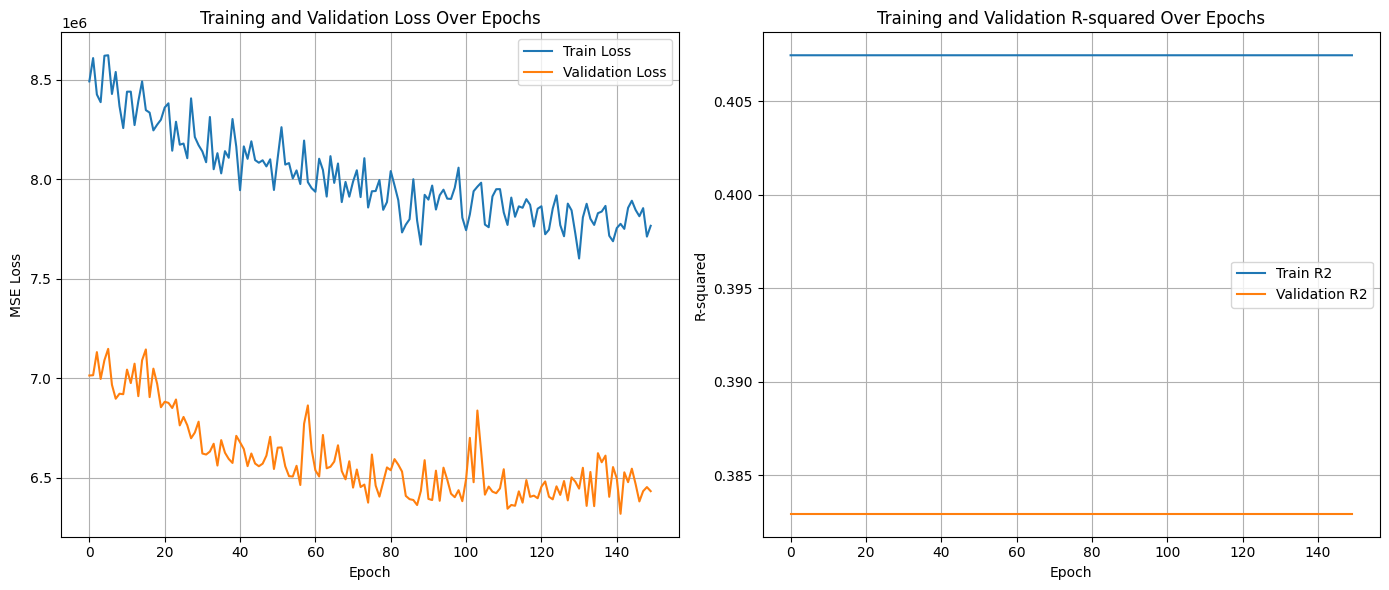

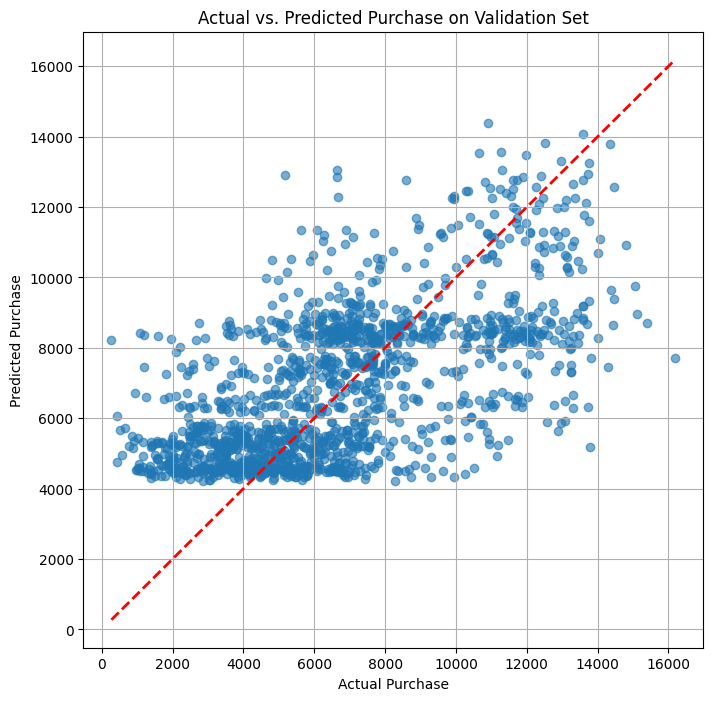

Final Training R-squared: 0.4075
Final Validation R-squared: 0.3830
Validation R-squared is below the acceptable threshold of 0.70. Consider further optimization.


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Function to calculate R-squared
def calculate_r2(y_true, y_pred):
    ss_total = torch.sum((y_true - torch.mean(y_true)) ** 2)
    ss_residual = torch.sum((y_true - y_pred) ** 2)
    if ss_total == 0:
        return 0.0  # Handle cases where y_true is constant
    return 1 - (ss_residual / ss_total)

# Calculate R-squared for training and validation sets
train_r2_scores = []
val_r2_scores = []

model.eval() # Set model to evaluation mode
with torch.no_grad():
    for epoch_idx in range(epochs): # Use epoch_idx to avoid conflict with the global 'epoch' variable
        # Calculate R2 for training data
        all_train_preds = []
        all_train_labels = []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            all_train_preds.append(outputs.cpu())
            all_train_labels.append(labels.cpu())
        train_preds = torch.cat(all_train_preds)
        train_labels = torch.cat(all_train_labels)
        train_r2 = calculate_r2(train_labels, train_preds)
        train_r2_scores.append(train_r2.item())

        # Calculate R2 for validation data
        all_val_preds = []
        all_val_labels = []
        for inputs_val, labels_val in val_loader:
            inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
            outputs_val = model(inputs_val)
            all_val_preds.append(outputs_val.cpu())
            all_val_labels.append(labels_val.cpu())
        val_preds = torch.cat(all_val_preds)
        val_labels = torch.cat(all_val_labels)
        val_r2 = calculate_r2(val_labels, val_preds)
        val_r2_scores.append(val_r2.item())

# Plotting Loss and R-squared
plt.figure(figsize=(14, 6))

# Plotting Loss
plt.subplot(1, 2, 1)
plt.plot(range(epochs), train_losses, label='Train Loss')
plt.plot(range(epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)

# Plotting R-squared
plt.subplot(1, 2, 2)
plt.plot(range(epochs), train_r2_scores, label='Train R2')
plt.plot(range(epochs), val_r2_scores, label='Validation R2')
plt.xlabel('Epoch')
plt.ylabel('R-squared')
plt.title('Training and Validation R-squared Over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Scatter plot of Real vs Predicted values on Validation Set
plt.figure(figsize=(8, 8))
plt.scatter(val_labels.numpy(), val_preds.numpy(), alpha=0.6)
plt.plot([val_labels.min(), val_labels.max()], [val_labels.min(), val_labels.max()], 'r--', lw=2)
plt.xlabel('Actual Purchase')
plt.ylabel('Predicted Purchase')
plt.title('Actual vs. Predicted Purchase on Validation Set')
plt.grid(True)
plt.show()

print(f"Final Training R-squared: {train_r2_scores[-1]:.4f}")
print(f"Final Validation R-squared: {val_r2_scores[-1]:.4f}")

# Check if R-squared meets the acceptable threshold
if val_r2_scores[-1] >= 0.70:
    print("Validation R-squared meets the acceptable threshold of 0.70.")
else:
    print("Validation R-squared is below the acceptable threshold of 0.70. Consider further optimization.")

### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

### 2d) Conclusiones finales (0.5 puntos)
Redactar de manera detallada las conclusiones finales y si se cumplió con el objetivo o no.